C:\Users\MANAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 241ms/step - loss: 0.1068 - val_loss: 0.0737
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 154s 328ms/step - loss: 0.0722 - val_loss: 0.0702
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 105ms/step - loss: 0.0696 - val_loss: 0.0681
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 129ms/step - loss: 0.0680 - val_loss: 0.0673
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - loss: 0.0671 - val_loss: 0.0668
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - loss: 0.0665 - val_loss: 0.0658
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - loss: 0.0660 - val_loss: 0.0653
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.0655 - val_loss: 0.0649
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.0652 - val_loss: 0.0651
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - loss: 0.0649 - val_loss: 0.0643
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


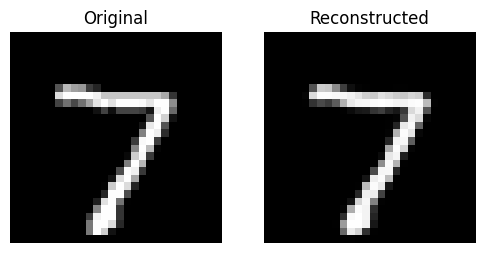

In [1]:


import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize values (0 to 255 --> 0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to (28, 28, 1) for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build Convolutional Autoencoder
model = models.Sequential()

# Encoder
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        padding='same', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), padding='same'))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2), padding='same'))

# Decoder
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.UpSampling2D((2,2)))

model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.UpSampling2D((2,2)))

model.add(layers.Conv2D(1, (3,3), activation='sigmoid', padding='same'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train model
model.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Predict reconstructed images
decoded_imgs = model.predict(x_test)

# Display original and reconstructed image
plt.figure(figsize=(6,3))

# Original Image
plt.subplot(1,2,1)
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis("off")

# Reconstructed Image
plt.subplot(1,2,2)
plt.imshow(decoded_imgs[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed")
plt.axis("off")

plt.show()